## AI-Based Handwritten Digit Generation Using GANs

### Generative Deep Learning Application

#### This project implements a Generative Adversarial Network (GAN)
#### using TensorFlow/Keras to generate handwritten digit images
#### similar to the MNIST dataset.


### Objectives

#### Understand Generative AI and GAN architecture
#### Preprocess MNIST images
#### Build Generator and Discriminator networks
#### Train the GAN using adversarial learning
#### Generate new handwritten digit images
#### Analyze Generator and Discriminator losses

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers

In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_train.shape[1:]

(28, 28)

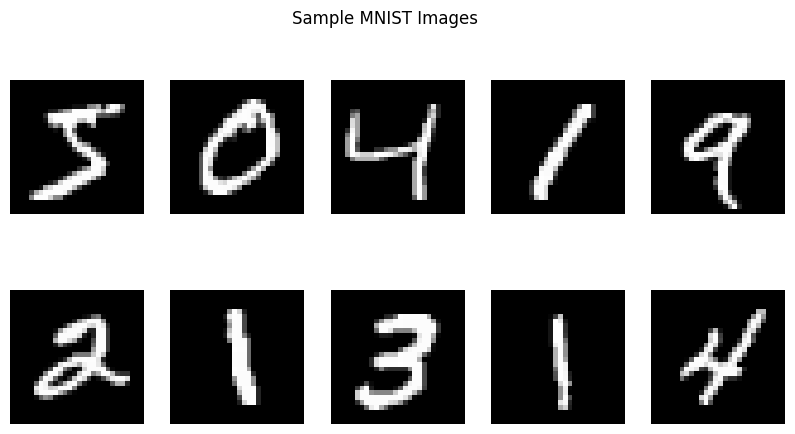

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
 plt.subplot(2, 5, i+1)
 plt.imshow(x_train[i], cmap="gray")
 plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.show()

In [7]:
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)
print("\n Shape:", x_train.shape)
print("\n Minimum:", x_train.min())
print("\n Maximum:", x_train.max())


 Shape: (60000, 28, 28, 1)

 Minimum: -1.0

 Maximum: 1.0


In [8]:
BUFFER_SIZE = 60000
BATCH_SIZE = 128
train_dataset = (
	tf.data.Dataset.from_tensor_slices(x_train)
	.shuffle(BUFFER_SIZE)
	.batch(BATCH_SIZE)
)

In [9]:
LATENT_DIM = 100
generator = tf.keras.Sequential([
	layers.Input(shape=(LATENT_DIM,)),
 layers.Dense(7 * 7 * 256, use_bias=False),
 layers.BatchNormalization(),
 layers.LeakyReLU(),
 layers.Reshape((7, 7, 256)),
 layers.Conv2DTranspose(
		128,
  kernel_size=5,
  strides=1,
  padding="same",
  use_bias=False
	),
 layers.BatchNormalization(),
 layers.LeakyReLU(),
 layers.Conv2DTranspose(
  64,
  kernel_size=5,
  strides=2,
  padding="same",
  use_bias=False
  ),
 layers.BatchNormalization(),
 layers.LeakyReLU(),
 layers.Conv2DTranspose(
		1,
  kernel_size=5,
  strides=2,
  padding="same",
  activation="tanh"
	)
])
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [10]:
noise =tf.random.normal([1, LATENT_DIM])
generated_image = generator(noise, training=False)
generated_image.shape

TensorShape([1, 28, 28, 1])

In [11]:
discriminator = tf.keras.Sequential([
	layers.Input(shape=(28, 28, 1)),
 layers.Conv2D(
		64,
  kernel_size=5,
  strides=2,
  padding="same"
	),
 layers.LeakyReLU(),
 layers.Dropout(0.3),
 layers.Conv2D(
		128,
  kernel_size=5,
  strides=2,
  padding="same"
	),
 layers.LeakyReLU(),
 layers.Dropout(0.3),
 layers.Flatten(),
 layers.Dense(1, activation="sigmoid")
])
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
decision = discriminator(generated_image)
decision.numpy()

array([[0.5004994]], dtype=float32)

In [13]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

In [14]:
def generator_loss(fake_output):
 return cross_entropy(tf.ones_like(fake_output), fake_output)

In [15]:
def discriminator_loss(real_output, fake_output):
 real_loss = cross_entropy(tf.ones_like(real_output), real_output)
 fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
 return real_loss + fake_loss

In [16]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [17]:
EPOCHS = 20
NOISE_DIM = 100
num_examples_to_generate = 25
seed = tf.random.normal([num_examples_to_generate, NOISE_DIM])

In [18]:
@tf.function
def train_step(images):
 noise = tf.random.normal(
		[BATCH_SIZE, NOISE_DIM]
	)
 with tf.GradientTape() as gen_tape, \
      tf.GradientTape() as disc_tape:
       generated_image = generator(noise, training=True)
       real_output = discriminator(images, training=True)
       fake_output = discriminator(generated_image, training=True)
       gen_loss = generator_loss(fake_output)
       disc_loss = discriminator_loss(real_output, fake_output)
       gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
       gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
       generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
       discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
       return gen_loss, disc_loss
       

In [19]:
os.makedirs("outputs", exist_ok=True)
def generate_and_save_images(model, epoch, test_input):
 predictions = model(test_input, training=False)
 fig = plt.figure(figsize=(8,8))
 for i in range(predictions.shape[0]):
  plt.Subplot(5, 5, i+1)
  plt.imshow(predictions[i, :, :, 0]*127.5 + 127.5, cmap="gray")
  plt.axis("off")
  plt.suptitle(f"Generated Digits - Epoch {epoch}")
  plt.savefig(f"outputs/generated_digits_epoch_{epoch:02d}.png",bbox_inches="tight")
  plt.show()
  plt.close()

In [ ]:
generator_losses = []
discriminator_losses = []
for epoch in range(1, EPOCHS + 1):
 epoch_gen_loss = []
 epoch_disc_loss = []
 for image_batch in train_dataset:
  gen_loss, disc_loss = train_step(image_batch)
  epoch_gen_loss.append(gen_loss.numpy())
  epoch_disc_loss.append(disc_loss.numpy())
  avg_gen_loss = np.mean(epoch_gen_loss)
  avg_disc_loss = np.mean(epoch_disc_loss)
  generator_losses.append(avg_gen_loss)
  discriminator_losses.append(avg_disc_loss)
  print(f"Epoch {epoch}/{EPOCHS} | - AI-Based Handwritten Digit.ipynb:14"
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"discriminator Loss: {avg_disc_loss:.4f}"
        )
  if epoch == 1 or epoch % 5 == 0:
			def generate_and_save_images(model, epoch, test_input):
				predictions = model(test_input, training=False)

				fig = plt.figure(figsize=(8, 8))

				for i in range(predictions.shape[0]):
					plt.subplot(5, 5, i + 1)
					plt.imshow(
						predictions[i, :, :, 0] * 127.5 + 127.5,
						cmap="gray"
					)
					plt.axis("off")

				plt.suptitle(f"Generated Digits - Epoch {epoch}")
				plt.savefig(
					f"outputs/generated_digits_epoch_{epoch:02d}.png",
					bbox_inches="tight"
				)
				plt.show()
				plt.close(fig)

Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6899 | discriminator Loss: 1.3883
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6707 | discriminator Loss: 1.3652
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6561 | discriminator Loss: 1.3372
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6455 | discriminator Loss: 1.3109
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6400 | discriminator Loss: 1.2818
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6370 | discriminator Loss: 1.2527
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6338 | discriminator Loss: 1.2280
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6280 | discriminator Loss: 1.2092
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6180 | discriminator Loss: 1.1982
Epoch 1/20 | - AI-Based Handwritten Digit.ipynb:14Generator Loss: 0.6077 | discrim

In [20]:
plt.figure(figsize=(10,5))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(True)
plt.savefig("outputs/loss_curves.png", bbox_inches="tight")
plt.show()

NameError: name 'generator_losses' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
epochs_to_display = [1, 5, 10, 15, 20]
for ax, epoch in zip(axes, epochs_to_display):
 image_path =(
		f"outputs/generated_digits_epoch_{epoch:02d}.png"
	)
if not os.path.exists(image_path):
		predictions = generator(seed, training=False)

		fig_missing, missing_axes = plt.subplots(5, 5, figsize=(8, 8))
		for missing_ax, prediction in zip(
			missing_axes.flat, predictions
		):
			missing_ax.imshow(
				prediction[:, :, 0] * 127.5 + 127.5,
				cmap="gray"
			)
			missing_ax.axis("off")

		fig_missing.suptitle(f"Generated Digits - Epoch {epoch}")
		fig_missing.tight_layout()
		fig_missing.savefig(image_path, bbox_inches="tight")
		plt.close(fig_missing)
image = plt.imread(image_path)
ax.imshow(image)
ax.set_title(f"Epoch{epoch}")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs("models", exist_ok=True)
generator.save("models/generator.keras")
discriminator.save("models/discriminator.keras")
print("Models saved successfully.")

In [ ]:
final_noise = tf.random.normal([25, NOISE_DIM])
final_images = generator(final_noise, training=False)
plt.figure(figsize=(8,8))
for i in range(25):
 plt.subplot(5, 5, i+1)
 plt.imshow(final_images[i, :, :, 0]* 127.5 + 127.5, cmap ="gray")
 plt.axis("off")
 plt.suptitle("Final Generated Handwritten Digits")
 plt.tight_layout()
 plt.show()